# Generate figure 4H: Regression analysis

In [1]:
# ---------------------------------------------------------------------------------------------------------------
import os
import rpy2

import pandas as pd
import sys, os
import matplotlib

#matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
 #simulation as sim,import_photometry_data as pi,
# from analysis_code import plot_behaviour as pl, saving as sv,  \
#   model_fitting as mf, plot_models as pm, import_behaviour_data as di, \
#   plot_photometry as plp, parallel_processing as pp

from RL_agents_two_step import mf, mb, latent_state, mf_forget_diffa, mb_forget_0_diffa, latent_state_rewasym

#dir_folder_variables = './data_variables/'
from analysis_code import saving as sv
from analysis_code import plot_photometry as plp

dir_folder_variables = 'data'

from functools import partial
from scipy import stats
from analysis_code import parallel_processing as pp

import pandas as pd
import numpy as np
#import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.datasets import load_iris
#from sklearn.feature_selection import GenericUnivariateSelect, SelectKBest, f_regression, r_regression, mutual_info_regression, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import non_negative_factorization, PCA
#from tabulate import tabulate
from collections import defaultdict
from scipy.stats import ttest_rel


from pandas.core.frame import DataFrame as DF

import seaborn as sns
sns.set(color_codes=True)
#np.random.seed(sum(map(ord, "distributions")))
from sklearn import linear_model  # packages for the logistic regression function to plot the logistic regression
from sklearn.linear_model import LogisticRegression # packages for the logistic regression function to plot the logistic regression
import scipy
from scipy import stats, integrate
from scipy.stats import mode
from scipy.stats.stats import pearsonr # Pearson's correlation
from copy import copy as copy
import operator as operator
import pylab

# Plotting tools
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%pylab inline
figsize(5, 5)

import glob

from IPython.display import clear_output

import os
# Added to avoid OMP:error#15
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# from pymer4.models import Lmer
from pymer4.models import lmer, glmer

# Setup rpy2 converter for pandas DataFrames and numpy arrays
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
from rpy2.robjects.conversion import Converter

rpy2_converter = Converter('pandas converter', template=default_converter)
rpy2_converter += pandas2ri.converter
rpy2_converter += numpy2ri.converter



/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_51066/1684000568.py:55: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr # Pearson's correlation
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['copy', 'pylab']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import pickle

In [3]:
# function to split the dataframe into subjectwise dataframes
def split_subjects(df):
    subjects = df.keys()
    subject_data = pd.DataFrame()
    for subject in subjects:

        subject_data = pd.concat([subject_data ,df_stim_sims[subject]])

    return subject_data

In [4]:
import random
def bernoulli(p):
  if random.random() <= p:
    return 1
  else:
    return 0


In [5]:

def extractTrialTypes(outStim_fullDF, metric = 'correct_next_fix'):

    # outDF0 = outStim_fullDF.loc[(outStim_fullDF['free_choice']==1) & (outStim_fullDF['free_next']==1)   &  (outStim_fullDF['rew_state'] != 2)  ]#& (outStim_fullDF['threshCrossed']==1)]
    outDF0 = outStim_fullDF

    outDF = outDF0.loc[ (outDF0['stim']==0)]
    RR_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ][metric].values

    M0 = [CR_0,RR_0,CN_0,RN_0]

    outDF = outDF0.loc[ (outDF0['stim']==1)]

    RR_1 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_1 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_1 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_1 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ] [metric].values

    M1 = [CR_1, RR_1,CN_1,RN_1]


    return M0,M1


def extractTrialTypesMerged(outStim_fullDF, metric = 'correct_next_fix'):

    # outDF0 = outStim_fullDF.loc[(outStim_fullDF['correct']==1) & (outStim_fullDF['free_choice']==1) & (outStim_fullDF['free_next']==1)   &  (outStim_fullDF['rew_state'] != 2)  ]#& (outStim_fullDF['threshCrossed']==1)]
    outDF = outStim_fullDF

    # outDF = outDF0.loc[ (outDF0['stim']==0)]
    RR_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ][metric].values

    M0 = [CR_0,RR_0,CN_0,RN_0]

    return M0

def perm_pairwiseTrialTypes(means_1, means_2,labelsSamples = ['Stim', 'No-stim']):

    # calculate for the conditions
    # CR: common reward

    condLabels = ['CR', 'RR','CN', 'RN']

    for i in range(len(condLabels)):
        print("Condition: "  + condLabels[i])

        x = means_1[i]
        x = x[~numpy.isnan(x)]

        y = means_2[i]
        y = y[~numpy.isnan(y)]

        res = permutation_test((x, y), statistic)


        if res.pvalue < 0.001:
            significant = '***'
        elif res.pvalue < 0.01:
            significant = '**'
        elif res.pvalue < 0.05:
            significant = '*'
        else:
            significant = ''

        print(""  + labelsSamples[0] + " - " + labelsSamples[1] + ": " + str(res.statistic) + " p-value: " + str(res.pvalue), significant)


In [6]:
def plotTrialTypes (M0,M1,M0_YFP,M1_YFP, metric = 'P(Correct Next) / After Threshold',locLegend = 'lower right'):
    colors = ['blue', 'lightblue','green', 'lightgreen']
    colors = ['#e97d68', '#e97d68','#a61945', '#a61945']

    plt.bar(0, np.nanmean(M0[0]), yerr=stats.sem(M0[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[0])
    plt.bar(1, np.nanmean(M1[0]), yerr=stats.sem(M1[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[1],hatch='//')
    plt.bar(2, np.nanmean(M0_YFP[0]), yerr=stats.sem(M0_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[2])
    plt.bar(3, np.nanmean(M1_YFP[0]), yerr=stats.sem(M1_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[3],hatch='//')

    plt.bar(4, np.nanmean(M0[1]), yerr=stats.sem(M0[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[0])
    plt.bar(5, np.nanmean(M1[1]), yerr=stats.sem(M1[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[1],hatch='//')
    plt.bar(6, np.nanmean(M0_YFP[1]), yerr=stats.sem(M0_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[2])
    plt.bar(7, np.nanmean(M1_YFP[1]), yerr=stats.sem(M1_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[3],hatch='//')

    plt.bar(8, np.nanmean(M0[2]), yerr=stats.sem(M0[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[0])
    plt.bar(9, np.nanmean(M1[2]), yerr=stats.sem(M1[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[1],hatch='//')
    plt.bar(10, np.nanmean(M0_YFP[2]), yerr=stats.sem(M0_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[2])
    plt.bar(11, np.nanmean(M1_YFP[2]), yerr=stats.sem(M1_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[3],hatch='//')

    plt.bar(12, np.nanmean(M0[3]), yerr=stats.sem(M0[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[0])
    plt.bar(13, np.nanmean(M1[3]), yerr=stats.sem(M1[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[1],hatch='//')
    plt.bar(14, np.nanmean(M0_YFP[3]), yerr=stats.sem(M0_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[2])
    plt.bar(15, np.nanmean(M1_YFP[3]), yerr=stats.sem(M1_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[3],hatch='//')


    plt.axhline(y=0.5, color='black', linestyle='--')
    plt.xticks([1.5, 5.5, 9.5, 13.5], ['Common\nReward', 'Rare\nReward', 'Common\nNo Reward', 'Rare\nNo Reward'], rotation=0)
    plt.ylabel(metric)

    # custom_lines = [plt.Line2D([0], [0], color=colors[0], lw=4),
    #                 plt.Line2D([0], [0], color=colors[1], lw=4),
    #                 plt.Line2D([0], [0], color=colors[2], lw=4),
    #                 plt.Line2D([0], [0], color=colors[3], lw=4)]
    
    from matplotlib.patches import Patch
    custom_lines = [Patch(facecolor=colors[0]),
                    Patch(facecolor=colors[1],hatch='//'),
                    Patch(facecolor=colors[2]),
                    Patch(facecolor=colors[3],hatch='//')]

    custom_labels = ['ChR2/ Stim = 0', 'ChR2/ Stim = 1', 'YFP/ Stim = 0', 'YFP/ Stim = 1']

    # Add the custom legend to the plot
    plt.legend(custom_lines, custom_labels, loc = locLegend)


    print('-- STIM = 0 --')
    perm_pairwiseTrialTypes(M0, M0_YFP,labelsSamples = ['ChR2', 'Sims'])
    print('-- STIM = 1 --')
    perm_pairwiseTrialTypes(M1, M1_YFP,labelsSamples = ['ChR2', 'Sims'])

    print('-- ChR2 --')
    perm_pairwiseTrialTypes(M0, M1,labelsSamples = ['Stim = 0 ', 'Stim = 1'])
    print('-- Sims --')
    perm_pairwiseTrialTypes(M0_YFP, M1_YFP,labelsSamples = ['Stim = 0 ', 'Stim = 1'])



def plotTrialTypesMerged (M0,M0_YFP, metric = 'P(Correct Next) / After Threshold',locLegend = 'lower right'):
    colors = ['blue', 'lightblue','green', 'lightgreen']
    colors = ['#e97d68', '#e97d68','#a61945', '#a61945']

    plt.bar(0, np.nanmean(M0[0]), yerr=stats.sem(M0[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[0])
    plt.bar(2, np.nanmean(M0_YFP[0]), yerr=stats.sem(M0_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[2])

    plt.bar(4, np.nanmean(M0[1]), yerr=stats.sem(M0[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[0])
    plt.bar(6, np.nanmean(M0_YFP[1]), yerr=stats.sem(M0_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[2])

    plt.bar(8, np.nanmean(M0[2]), yerr=stats.sem(M0[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[0])
    plt.bar(10, np.nanmean(M0_YFP[2]), yerr=stats.sem(M0_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[2])

    plt.bar(12, np.nanmean(M0[3]), yerr=stats.sem(M0[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[0])
    plt.bar(14, np.nanmean(M0_YFP[3]), yerr=stats.sem(M0_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[2])


    plt.axhline(y=0.5, color='black', linestyle='--')
    plt.xticks([1.5, 5.5, 9.5, 13.5], ['Common\nReward', 'Rare\nReward', 'Common\nNo Reward', 'Rare\nNo Reward'], rotation=0)
    plt.ylabel(metric)

    custom_lines = [plt.Line2D([0], [0], color=colors[0], lw=2),
                    plt.Line2D([0], [0], color=colors[2], lw=2),
                   ]
    custom_labels = ['ChR2','YFP']

    # Add the custom legend to the plot
    plt.legend(custom_lines, custom_labels, loc = locLegend)

    print('-- Chr2 vs YFP --')
    perm_pairwiseTrialTypes(M0, M0_YFP,labelsSamples = ['ChR2', 'YFP'])


In [7]:
from scipy.stats import permutation_test

def statistic(x, y, axis = 0  ):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

def statisticNan(x, y, axis):
    return np.nanmean(x, axis=axis) - np.nanmean(y, axis=axis)



def perm_pairwise(means_1, means_2,labelsSamples = ['Stim', 'No-stim']):

    # calculate for the conditions
    # CR: common reward



    condLabels = ['CR', 'CN', 'RR', 'RN']

    for i in range(len(condLabels)):
        print("Condition: "  + condLabels[i])

        x = np.array(means_1[i])
        x = x[~numpy.isnan(x)]

        y = np.array(means_2[i])
        y = y[~numpy.isnan(y)]

        res = permutation_test((x, y), statistic)


        if res.pvalue < 0.001:
            significant = '***'
        elif res.pvalue < 0.01:
            significant = '**'
        elif res.pvalue < 0.05:
            significant = '*'
        else:
            significant = ''

        print(""  + labelsSamples[0] + " - " + labelsSamples[1] + ": " + str(res.statistic) + " p-value: " + str(res.pvalue), significant)





In [8]:
def session_latencies(session, type):
  '''
  return latency between events
  type: 'start', 'choice', 'second-step', 'ITI', 'ITI-choice', 'ITI-start', 'ITI_poke_5', 'ITI_end_consump_init_trial'
  '''
  if type == 'start':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'init_trial', 'poke_5', ['init_trial', 'poke_5'])
  elif type == 'choice':
    events = ['choice_state', 'choose_right', 'choose_left']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]
  elif type == 'second_step':
    events = ['up_state', 'down_state', 'choose_up', 'choose_down']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]

  elif type == 'second_step_poke':
    events = ['cue_up_state', 'poke_1']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1_1 = [session.events[x][0] for x in all_id[::2]]
    times_e2_1 = [session.events[x][0] for x in all_id[1::2]]

    events = ['cue_down_state', 'poke_9']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1_2 = [session.events[x][0] for x in all_id[::2]]
    times_e2_2 = [session.events[x][0] for x in all_id[1::2]]

    times_e1 = sorted(times_e1_1+times_e1_2)
    times_e2 = sorted(times_e2_1+times_e2_2)

  elif type == 'ITI':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'init_trial', ['inter_trial_interval', 'init_trial'])
  elif type == 'ITI-choice':
    events = ['inter_trial_interval', 'choose_right', 'choose_left']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                 if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]
  elif type == 'ITI-start':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'choice_state', ['inter_trial_interval', 'choice_state'])

  elif type == 'ITI_poke_5':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'poke_5', ['inter_trial_interval', 'poke_5'])

  elif type == 'ITI_end_consump_init_trial':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'reward_consumption', 'choice_state', ['reward_consumption', 'choice_state'])


  latency = [e2 - e1 for e1, e2 in zip(times_e1, times_e2)][:len(times_e1)]

  return np.asarray(latency)

# Plot performance

In [9]:
def get_perf_mean_groups(outStim_DF):
        perfStimDF = pd.DataFrame()
        perfBlock = []
        stimBlock = []
        perfNoStimBlock = []
        numTrialsBlock = []


        perfBlockBefore = []
        stimBlockBefore = []
        perfNoStimBlockBefore = []
        numTrialsBlockBefore = []

        # outStim_DF = outStim_fullDF

        subjName = []
        sessionName = []


        for ss in outStim_DF.subject.unique():
                subject_data = outStim_DF.loc[outStim_DF['subject'] == ss]

                countSubj =0


                for i in subject_data.session.unique():


                        countSess = 0
                        sess_data = subject_data.loc[subject_data['session'] == i]

                        for j in sess_data.block.unique():
                                block_data = sess_data.loc[sess_data['block'] == j]


                                # Extract Performance After Threshold for each block
                                selctBlk = block_data.loc[(block_data['threshCrossed'] == 1) & (block_data.rew_state.unique() != 2)]

                                if len(selctBlk) > 5 & (block_data.rew_state.unique()[0] != 2):  # take the duration of the block if it's longer than 5 trials and only bias blocks (rew_state != 2)

                                        countSess = countSess + 1
                                        countSubj = countSubj + 1

                                        selctBlk = selctBlk.loc[(selctBlk['free_choice'] == 1) ]

                                        perfBlock.append(np.nanmean(selctBlk['correct'].values))
                                        stimBlock.append(selctBlk['stim'].sum())
                                        numTrialsBlock.append(len(selctBlk))
                                        perfNoStimBlock.append(np.nanmean(selctBlk.loc[selctBlk['stim'] == 0]['correct'].values))



                                # # Extract Performance Before Threshold
                                        selctBlk = block_data.loc[(block_data['threshCrossed'] == 0) & (block_data.rew_state.unique() != 2)]

                                        selctBlk = selctBlk.loc[(selctBlk['free_choice'] == 1) ]
                                        perfBlockBefore.append(np.nanmean(selctBlk['correct'].values))
                                        stimBlockBefore.append(selctBlk['stim'].sum())
                                        numTrialsBlockBefore.append(len(selctBlk))
                                        perfNoStimBlockBefore.append(np.nanmean(selctBlk.loc[selctBlk['stim'] == 0]['correct'].values))



                        sessionName.extend([i]*countSess)
                subjName.extend([ss]*countSubj)




        perfStimDF['subject'] = subjName
        perfStimDF['session'] = sessionName

        perfStimDF['performanceBlock'] = perfBlock
        perfStimDF['stimBlock'] = stimBlock
        perfStimDF['performanceNoStimBlock'] = perfNoStimBlock
        perfStimDF['numTrialsBlock'] = numTrialsBlock

        perfStimDF['performanceBlockBefore'] = perfBlockBefore
        perfStimDF['stimBlockBefore'] = stimBlockBefore
        perfStimDF['performanceNoStimBlockBefore'] = perfNoStimBlockBefore
        perfStimDF['numTrialsBlockBefore'] = numTrialsBlockBefore

        return perfStimDF


In [10]:
def add_threshCross(ooDF ,movAverageVar = "mov_average", threshold = 0.8):

    # create empty dimension for the average of the past XX trials
    ooDF['threshCrossed'] = 0

    for i  in ooDF.subject.unique():
            dfPart = ooDF[ooDF.subject == i]
            for j in dfPart.session.unique():
                dfSess = dfPart[dfPart.session == j].reset_index(drop=True)
                for k in dfSess.block.unique():
                    dfBlock = dfSess[dfSess.block == k]
                    threshCrossMov = []
                    threshCrossed = 0

                    for l in  dfBlock.trial.unique():
                        # if  (dfBlock[dfBlock.trial == l][movAverageVar].iloc[0] > threshold) | (threshCrossed == 1):
                        if  ( (dfBlock[dfBlock.trial == l][movAverageVar].iloc[0] > threshold)  & (dfBlock[dfBlock.trial == l]['trialRev'].iloc[0] < 16 ))  | (threshCrossed == 1):

                            threshCrossed = 1
                            threshCrossMov.append(threshCrossed)
                        else:
                            threshCrossed = 0
                            threshCrossMov.append(threshCrossed)



                    begIdx = ooDF.loc[(ooDF['subject']== i) & (ooDF['session']== j) & (ooDF['block']== k) ].index[0]
                    endIdx = ooDF.loc[(ooDF['subject']== i) & (ooDF['session']== j) & (ooDF['block']== k) ].index[-1]

                    ooDF.loc[begIdx:endIdx , 'threshCrossed'] =threshCrossMov

    # also include correct_next that assumes the correct from the past block for the last element
    #
    ooDF['correct_next_fix'] =  ooDF['correct_next'] * (ooDF['trialRev'] > 1 ) + np.abs(1- ooDF['correct_next']) * (ooDF['trialRev'] == 1 )


    return ooDF

In [11]:
# function to split the dataframe into subjectwise dataframes
def split_subjects_full(df):
    subjects = df['subject'].unique()
    subject_data = {}
    for subject in subjects:
        subject_data[subject] = df[df['subject'] == subject]
    return subject_data

In [12]:

def createFullDF_full (subjectwise_outcome_cue):
    all_data = []
    for ss in subjectwise_outcome_cue.keys():
        subject_data = subjectwise_outcome_cue[ss]
        session_data = []
        for i in range(len(subject_data)):
                    session = pd.DataFrame.from_dict(subject_data['sessions'].tolist()[i].trial_data)
                    blocks = subject_data['sessions'].tolist()[i].blocks
                    block_lengths = blocks['start_trials']

                    block_trial_data = []
                    reward_states = blocks['reward_states']


                    # load latency data (already shifted to include the value of the next trail)

                    latencys_init = session_latencies(subject_data['sessions'].tolist()[i],'start')
                    latencys_choice = session_latencies(subject_data['sessions'].tolist()[i],'choice')

                    latIn = latencys_init[1:]
                    latCho = latencys_choice [1:]

                    if len(latIn) == len(session):
                        latencyInit = latIn
                    else:
                        latencyInit = np.append(latIn,np.nan)

                    if len(latCho) == len(session):
                        latencyChoice = latCho
                    else:
                        latencyChoice = np.append(latCho,np.nan)

                    # # median split latency for next trial, high latency = 1; low latency = 0
                    # session['split_latency_init_next'] = (session['latency_init_next'] > session['latency_init_next'].median())*1



                    for j in range(len(block_lengths)):

                        if j < len(block_lengths)-1:
                            sess1 = session.iloc[block_lengths[j]:block_lengths[j+1]].copy()
                            sess1['block'] = j
                            sess1['trial'] = range(len(sess1))
                            sess1['trialRev'] = [len(sess1) - x for x in range(len(sess1))]

                            sess1['blockStage'] = [0]*int(len(sess1)/2) + [1]*(len(sess1) - int(len(sess1)/2))

                            if len(sess1)>20:
                                sess1['blockLast10'] = [0]*(len(sess1)-10) + [1]*10
                            else:
                                 sess1['blockLast10'] = 0


                            if len(sess1)>30:
                                sess1['blockLast20'] = [0]*(len(sess1)-20) + [1]*20
                            else:
                                 sess1['blockLast20'] = 0



                            block_trial_data.append(sess1)
                        else:
                            sess1 = session.iloc[block_lengths[j]:].copy()
                            sess1['block'] = j
                            sess1['trial'] = range(len(sess1))
                            sess1['trialRev'] = [len(sess1) - x for x in range(len(sess1))]

                            sess1['blockStage'] = [0]*int(len(sess1)/2) + [1]*(len(sess1) - int(len(sess1)/2))
                            if len(sess1)>20:
                                sess1['blockLast10'] = [0]*(len(sess1)-10) + [1]*10
                            else:
                                 sess1['blockLast10'] = 0


                            if len(sess1)>30:
                                sess1['blockLast20'] = [0]*(len(sess1)-20) + [1]*20
                            else:
                                 sess1['blockLast20'] = 0





                            block_trial_data.append(sess1)




                    block_trial_data =   pd.concat(block_trial_data)
                    block_trial_data['transition_type'] = blocks['trial_trans_state']
                    block_trial_data['rew_state'] =  blocks['trial_rew_state']

                    block_trial_data['latency_init_next'] =  latencyInit
                    block_trial_data['latency_choice_next'] =  latencyChoice

                    block_trial_data['log_latency_init_next'] =  np.log(latencyInit)
                    block_trial_data['log_latency_choice_next'] =  np.log(latencyChoice)

                    # add the type of the previous block (bias or balanced)
                    prevBlockRewState = -1

                    blockTypeSS = []

                    for j in range(len(block_trial_data['block'].unique())):
                            sess1 = block_trial_data.loc[block_trial_data['block'] == j]


                            blockTypeSS.extend([prevBlockRewState]*len(sess1))
                            prevBlockRewState = sess1['rew_state'].unique()[0]



                    block_trial_data['prev_rew_state'] = blockTypeSS


                    block_trial_data['correct'] =   ~block_trial_data['choices'].astype(bool) == (block_trial_data['transition_type'].values ^ block_trial_data['rew_state'].values)   ## extracted from plot_behaviour.py code by Blanco's code, line 412     if correct_select == True: \\  correct = ((~choices.astype(bool)).astype(int) == (transition_type ^ rew_state)
                    block_trial_data['correct_neutral'] =   (block_trial_data['correct'] == 1) *1 +  (block_trial_data['correct'] == 0) *-1 + (block_trial_data['rew_state'] ==2)
                    block_trial_data['common_transition'] = ((block_trial_data['transition_type'] == False) & (block_trial_data ['transitions'] ==0)) | ((block_trial_data['transition_type'] == True) & (block_trial_data ['transitions'] ==1))
                    block_trial_data['stay_next'] = (block_trial_data['choices'][1:].reset_index(drop = True) == block_trial_data['choices'][:-1].reset_index(drop = True)).astype(int)
                    block_trial_data['correct_next'] = (block_trial_data['correct'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['free_next'] = (block_trial_data['free_choice'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['common_next'] = (block_trial_data['common_transition'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['stim_next'] = (block_trial_data['stim'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['outcomes_next'] = (block_trial_data['outcomes'][1:].reset_index(drop=True)).astype(int)
                    # block_trial_data['latency_init_next'] = (block_trial_data['latency_init'][1:].reset_index(drop=True))
                    # block_trial_data['latency_choice_next'] = (block_trial_data['latency_choice'][1:].reset_index(drop=True))

                    block_trial_data['session'] = i



                    session_data.append(block_trial_data)




        session_data = pd.concat(session_data)
        session_data['subject'] = ss
        all_data.append(session_data)
    all_data = pd.concat(all_data)
    all_data = all_data.reset_index(drop = True)
    return all_data



# Extract  data

In [13]:
df_stim_opto = pd.read_pickle('data/df_stim_opto.pkl')


In [14]:

df_ChR2 = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'outcome_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF = createFullDF_full (subjectwise_outcome_cue)

df_YFP = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'outcome_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP = createFullDF_full (subjectwise_outcome_cue)


df_ChR2_ss = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'ss_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_ss = createFullDF_full (subjectwise_outcome_cue)

df_YFP_ss = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'ss_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP_ss = createFullDF_full (subjectwise_outcome_cue)


df_ChR2_base = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'baseline']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_base = createFullDF_full (subjectwise_outcome_cue)

df_YFP_base = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'baseline']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP_base = createFullDF_full (subjectwise_outcome_cue)



In [15]:
movAverageVar = "mov_average"
thresholdUsed = 0.75
outStim_fullDF = add_threshCross(outStim_fullDF ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP = add_threshCross(outStim_fullDF_YFP ,movAverageVar = movAverageVar, threshold = thresholdUsed)

outStim_fullDF_ss = add_threshCross(outStim_fullDF_ss ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP_ss = add_threshCross(outStim_fullDF_YFP_ss ,movAverageVar = movAverageVar, threshold = thresholdUsed)

outStim_fullDF_base = add_threshCross(outStim_fullDF_base ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP_base = add_threshCross(outStim_fullDF_YFP_base ,movAverageVar = movAverageVar, threshold = thresholdUsed)


--------

# Regression Balanced blocks, excluding impossible trials, separating experimental groups

### plot separate conditions 

In [31]:
def extractStimPossible(outStim_fullDF):
    stimplusAll = []
    for i in outStim_fullDF.subject.unique():
        outStim_fullDF_part = outStim_fullDF.loc[(outStim_fullDF['subject'] == i)]
        for j in outStim_fullDF_part.session.unique():
            outStim_fullDF_part_sess = outStim_fullDF_part.loc[(outStim_fullDF_part['session'] == j)]
            end_index = outStim_fullDF_part_sess.index[-1]
            # select only stimulation trials =1
            outStim_fullDF_part_sess_stim = outStim_fullDF_part_sess.loc[(outStim_fullDF_part_sess['stim'] == 1)]

            stimplus1 = outStim_fullDF_part_sess_stim.index.values+1
            stimplus2 = outStim_fullDF_part_sess_stim.index.values+2
            stimplus = np.concatenate((stimplus1,stimplus2))

            # remove elements in stimplus that are greater than end_index
            stimplus = stimplus[stimplus <= end_index]

            stimplusAll.extend(stimplus)

    # sort stimplusAll
    stimplusAll = sorted(stimplusAll)
    return stimplusAll

In [43]:
# select all indexes in dataframe that are not in stimplusAll
stimplusAll = extractStimPossible(outStim_fullDF)
outDF0 = outStim_fullDF.loc[~outStim_fullDF.index.isin(stimplusAll)]
outDF0 = outDF0.loc[(outDF0['free_choice']==1) & (outDF0['free_next']==1)   &  (outDF0['rew_state'] ==2 ) & (outDF0['trialRev']!=1 ) ]

stimplusAll = extractStimPossible(outStim_fullDF_YFP)
outDF0_YFP = outStim_fullDF_YFP.loc[~outStim_fullDF_YFP.index.isin(stimplusAll)]
outDF0_YFP = outDF0_YFP.loc[(outDF0_YFP['free_choice']==1) & (outDF0_YFP['free_next']==1)   &  (outDF0_YFP['rew_state'] ==2 ) & (outDF0_YFP['trialRev']!=1 ) ]

outDF0_YFP['rare_transition'] = outDF0_YFP['common_transition'].apply(lambda x: True if x == False else False)
outDF0['rare_transition'] = outDF0['common_transition'].apply(lambda x: True if x == False else False)

In [ ]:
# For Chr2

# oFree1 = outDF0.loc[(outDF0['free_choice']==1) & (outDF0['free_next']==1) & (outDF0['rew_state'] ==2) & (outDF0['trialRev']!=1)].copy()

model_Chr2 = lmer("stay_next ~ C(choices) + C(rare_transition)*C(outcomes)*C(stim)  + ( C(choices) + C(rare_transition)*C(outcomes)*C(stim)|subject)",
             data=outDF0, family = 'binomial')

print(model_Chr2.fit())

# For YFP
# oFree1_YFP = outDF0_YFP.loc[(outDF0_YFP['free_choice']==1) & (outDF0_YFP['free_next']==1) & (outDF0_YFP['rew_state'] ==2) & (outDF0_YFP['trialRev']!=1)].copy()

model_YFP = lmer("stay_next ~ C(choices) + C(rare_transition)*C(outcomes)*C(stim)  + ( C(choices) + C(rare_transition)*C(outcomes)*C(stim)|subject)",
             data=outDF0_YFP, family = 'binomial')

print(model_YFP.fit())

In [ ]:
# with localconverter(converter):
model_Chr2 = lmer("stay_next ~ C(choices) + C(rare_transition)*C(outcomes)*C(stim)  + ( C(choices) + C(rare_transition)*C(outcomes)*C(stim)|subject)",
                data=outDF0, family = 'binomial')
print(model_Chr2.fit())



In [118]:
coefs

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.113697,0.825593,1.401802,0.146995,3.045599,2.283235,4.062513,0.752818,0.695422,0.802470,7.576445,3.551508e-14,***
C(choices)1,0.150342,-0.203336,0.504021,0.180451,1.162232,0.816004,1.655363,0.537515,0.449340,0.623404,0.833146,4.047626e-01,
C(rare_transition)TRUE,-0.619238,-1.190950,-0.047525,0.291695,0.538355,0.303932,0.953587,0.349955,0.233089,0.488121,-2.122891,3.376298e-02,*
C(outcomes)1,1.572887,0.939483,2.206291,0.323171,4.820545,2.558658,9.081970,0.828195,0.718995,0.900813,4.867038,1.132834e-06,***
C(stim)1,-0.031214,-0.479802,0.417374,0.228875,0.969268,0.618906,1.517970,0.492197,0.382299,0.602855,-0.136379,8.915216e-01,
C(rare_transition)TRUE:C(outcomes)1,-1.640699,-2.759670,-0.521728,0.570914,0.193845,0.063313,0.593494,0.162370,0.059543,0.372448,-2.873810,4.055526e-03,**
C(rare_transition)TRUE:C(stim)1,0.590498,-0.223933,1.404930,0.415534,1.804887,0.799368,4.075241,0.643479,0.444249,0.802965,1.421059,1.552997e-01,
C(outcomes)1:C(stim)1,0.522871,-0.472294,1.518035,0.507746,1.686863,0.623570,4.563252,0.627819,0.384073,0.820249,1.029787,3.031101e-01,
C(rare_transition)TRUE:C(outcomes)1:C(stim)1,-2.018907,-3.299589,-0.738225,0.653421,0.132801,0.036898,0.477961,0.117232,0.035585,0.323392,-3.089749,2.003256e-03,**


In [119]:
coefs2

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.993054,0.570836,1.415273,0.215422,2.699467,1.769746,4.117611,0.729691,0.638956,0.804596,4.609819,0.000004,***
C(choices)1,-0.031084,-0.478957,0.416788,0.228511,0.969394,0.619429,1.517081,0.492230,0.382498,0.602714,-0.136031,0.891797,
C(rare_transition)TRUE,-0.134637,-0.917720,0.648445,0.399539,0.874033,0.399429,1.912565,0.466391,0.285423,0.656660,-0.336982,0.736131,
C(outcomes)1,1.644375,0.712324,2.576426,0.475545,5.177773,2.038725,13.150050,0.838129,0.670915,0.929329,3.457877,0.000544,***
C(stim)1,-0.244282,-0.766359,0.277794,0.266370,0.783267,0.464702,1.320215,0.439231,0.317267,0.569005,-0.917076,0.359103,
C(rare_transition)TRUE:C(outcomes)1,-2.947643,-4.205615,-1.689670,0.641834,0.052463,0.014912,0.184580,0.049848,0.014693,0.155819,-4.592528,0.000004,***
C(rare_transition)TRUE:C(stim)1,0.006753,-1.197836,1.211342,0.614598,1.006776,0.301847,3.357988,0.501688,0.231860,0.770536,0.010987,0.991234,
C(outcomes)1:C(stim)1,0.064194,-0.997535,1.125923,0.541708,1.066299,0.368787,3.083061,0.516043,0.269426,0.755086,0.118503,0.905670,
C(rare_transition)TRUE:C(outcomes)1:C(stim)1,0.950107,-0.813239,2.713454,0.899683,2.585987,0.443419,15.081274,0.721137,0.307201,0.937816,1.056047,0.290947,


# generate plot for figure 4H and SI 

In [ ]:
# generate plot showing the coefficients of the model

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(4, 6))

labelsReg = ['Bias', 'Rare Transition','Outcome', 'Stim', 'Rare Transition X\n Outcome', 'Rare Transition X\n Stim', 'Outcome X\n Stim', 'Rare Transition X\n Outcome X\n Stim']

# Check the structure
print(coefs)


# define a color palette with arbitrary colors, all the colorrs should be identical grey except the last one which should be a different color
palette = ['#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#FF6347']  # Last color is tomato red
palette = ['#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#FF6347']  # Last color is tomato red

# Add a significance marker (e.g., * if p < 0.05)
# coefs['Sig'] = coefs['P-val'].apply(lambda p: '*' if p < 0.05 else '')

# Exclude intercept if desired
plot_data = coefs.reset_index()
plot_data = plot_data[plot_data['index'] != '(Intercept)']

# Add error bars (using 2*SE as an approximation for 95% CI)
x = range(len(plot_data))
for i in x:
    ax1.errorbar(
        x=i,
        y=plot_data['Estimate'].iloc[i],
        yerr=2 * plot_data['SE'].iloc[i],
        fmt='none',
        c='red' if i == len(plot_data) - 1 else 'black',
        elinewidth=6,
        capsize=10,
        zorder=1
    )

# sns.barplot(x='index', y='Estimate', data=plot_data, palette=palette, edgecolor='none', width=0.5, ax=ax1)



# Annotate with significance
for i, row in plot_data.iterrows():
    ax1.text(i-1, row['Estimate'] + np.abs(row['Estimate']*1.5), row['Sig'], ha='center', va='bottom', fontsize=20, color='black')

ax1.axhline(0, color='gray', linestyle='--')
# change x-ticks to show the index names
ax1.set_xticks(range(len(plot_data)), labelsReg , rotation=75,fontsize=20)
ax1.tick_params(axis='y', labelsize=20) # Adjust labelsize as desired
ax1.set_xlabel('')
ax1.set_ylabel('Regression Coefficient', fontsize=20)
ax1.set_title('P(Stay)', fontsize=20)
sns.despine()

sns.set_style("white") 

# save the figure as svg
plt.tight_layout()
plt.savefig('regressions_results/pymer4_model_NoImpossibleTrials_BalanceBlocks_Groups_Chr2_YFP_skinny.svg', format='svg', bbox_inches='tight')

plt.show()

                                              Estimate    2.5_ci   97.5_ci  \
(Intercept)                                   1.113697  0.825593  1.401802   
C(choices)1                                   0.150342 -0.203336  0.504021   
C(rare_transition)TRUE                       -0.619238 -1.190950 -0.047525   
C(outcomes)1                                  1.572887  0.939483  2.206291   
C(stim)1                                     -0.031214 -0.479802  0.417374   
C(rare_transition)TRUE:C(outcomes)1          -1.640699 -2.759670 -0.521728   
C(rare_transition)TRUE:C(stim)1               0.590498 -0.223933  1.404930   
C(outcomes)1:C(stim)1                         0.522871 -0.472294  1.518035   
C(rare_transition)TRUE:C(outcomes)1:C(stim)1 -2.018907 -3.299589 -0.738225   

                                                    SE        OR  OR_2.5_ci  \
(Intercept)                                   0.146995  3.045599   2.283235   
C(choices)1                                   0.180451  1.162

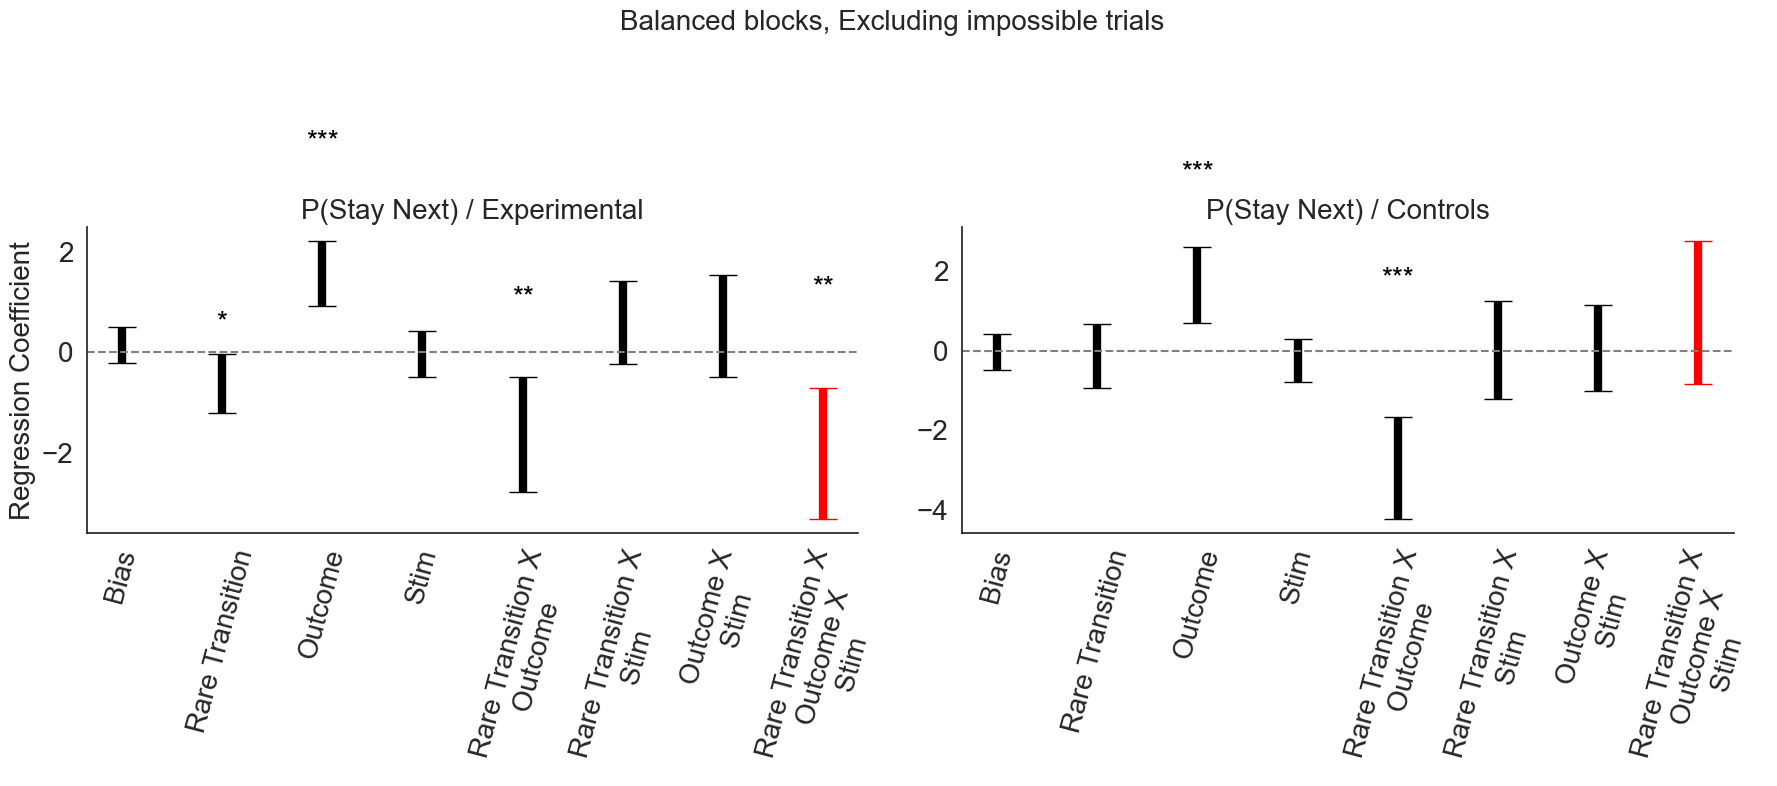

In [39]:
# generate plot showing the coefficients of the model

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(18, 8))

labelsReg = ['Bias', 'Rare Transition','Outcome', 'Stim', 'Rare Transition X\n Outcome', 'Rare Transition X\n Stim', 'Outcome X\n Stim', 'Rare Transition X\n Outcome X\n Stim']

# Check the structure
print(coefs)


# define a color palette with arbitrary colors, all the colorrs should be identical grey except the last one which should be a different color
palette = ['#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#FF6347']  # Last color is tomato red
palette = ['#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#808080', '#FF6347']  # Last color is tomato red

# Add a significance marker (e.g., * if p < 0.05)
# coefs['Sig'] = coefs['P-val'].apply(lambda p: '*' if p < 0.05 else '')

# Exclude intercept if desired
plot_data = coefs.reset_index()
plot_data = plot_data[plot_data['index'] != '(Intercept)']

# Add error bars (using 2*SE as an approximation for 95% CI)
x = range(len(plot_data))
for i in x:
    ax1.errorbar(
        x=i,
        y=plot_data['Estimate'].iloc[i],
        yerr=2 * plot_data['SE'].iloc[i],
        fmt='none',
        c='red' if i == len(plot_data) - 1 else 'black',
        elinewidth=6,
        capsize=10,
        zorder=1
    )

# sns.barplot(x='index', y='Estimate', data=plot_data, palette=palette, edgecolor='none', width=0.5, ax=ax1)



# Annotate with significance
for i, row in plot_data.iterrows():
    ax1.text(i-1, row['Estimate'] + np.abs(row['Estimate']*1.5), row['Sig'], ha='center', va='bottom', fontsize=20, color='black')

ax1.axhline(0, color='gray', linestyle='--')
# change x-ticks to show the index names
ax1.set_xticks(range(len(plot_data)), labelsReg , rotation=75,fontsize=20)
ax1.tick_params(axis='y', labelsize=20) # Adjust labelsize as desired
ax1.set_xlabel('')
ax1.set_ylabel('Regression Coefficient', fontsize=20)
ax1.set_title('P(Stay Next) / Experimental', fontsize=20)
sns.despine()


# generate subplot for YFP


# Add a significance marker (e.g., * if p < 0.05)
# coefs['Sig'] = coefs2['P-val'].apply(lambda p: '*' if p < 0.05 else '')

# Exclude intercept if desired
plot_data = coefs2.reset_index()
plot_data = plot_data[plot_data['index'] != '(Intercept)']


# Add error bars (using 2*SE as an approximation for 95% CI)
x = range(len(plot_data))
for i in x:
    ax2.errorbar(
        x=i,
        y=plot_data['Estimate'].iloc[i],
        yerr=2 * plot_data['SE'].iloc[i],
        fmt='none',
        c='red' if i == len(plot_data) - 1 else 'black',
        elinewidth=6,
        capsize=10,
        zorder=1
    )

# sns.barplot(x='index', y='Estimate', data=plot_data, palette=palette, edgecolor='none', width=0.5, ax=ax2)


# Annotate with significance
for i, row in plot_data.iterrows():
    ax2.text(i-1, row['Estimate'] + np.abs(row['Estimate']*1.5), row['Sig'], ha='center', va='bottom', fontsize=20, color='black')

ax2.axhline(0, color='gray', linestyle='--')
# change x-ticks to show the index names
ax2.set_xticks(range(len(plot_data)), labelsReg , rotation=75,fontsize=20)
ax2.tick_params(axis='y', labelsize=20) # Adjust labelsize as desired

ax2.set_xlabel('')
ax2.set_ylabel('', fontsize=20)
ax2.set_title('P(Stay Next) / Controls', fontsize=20)
sns.despine()

plt.suptitle('Balanced blocks, Excluding impossible trials', fontsize=20)

sns.set_style("white") 

# save the figure as svg
plt.tight_layout()
plt.savefig('regressions_results/pymer4_model_NoImpossibleTrials_BalanceBlocks_Groups_Chr2_YFP.svg', format='svg', bbox_inches='tight')

plt.show()